Обучение HyperImpute (missforest) на 7 признаках >>> 
Запуск Optuna (5 итераций) >>>

[Optuna] Лучшие найденные параметры:
  n_estimators: 100
  max_depth: 32
  min_samples_split: 3
  min_samples_leaf: 5
  max_features: log2
  class_weight: None
[Optuna] Лучший Validation F1 Weighted: 0.8519

Обучение финальной модели RandomForest >>>

Отчет по классификации (Validation):
               precision    recall  f1-score   support

 Argillaceous       0.87      0.94      0.91    188834
   Carbonates       0.85      0.62      0.72     15501
         Coal       0.79      0.48      0.60       514
   Evaporites       0.99      0.94      0.96      4139
Siliciclastic       0.80      0.67      0.73     67254

     accuracy                           0.86    276242
    macro avg       0.86      0.73      0.78    276242
 weighted avg       0.85      0.86      0.85    276242

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/hyperimpute_rf_test/

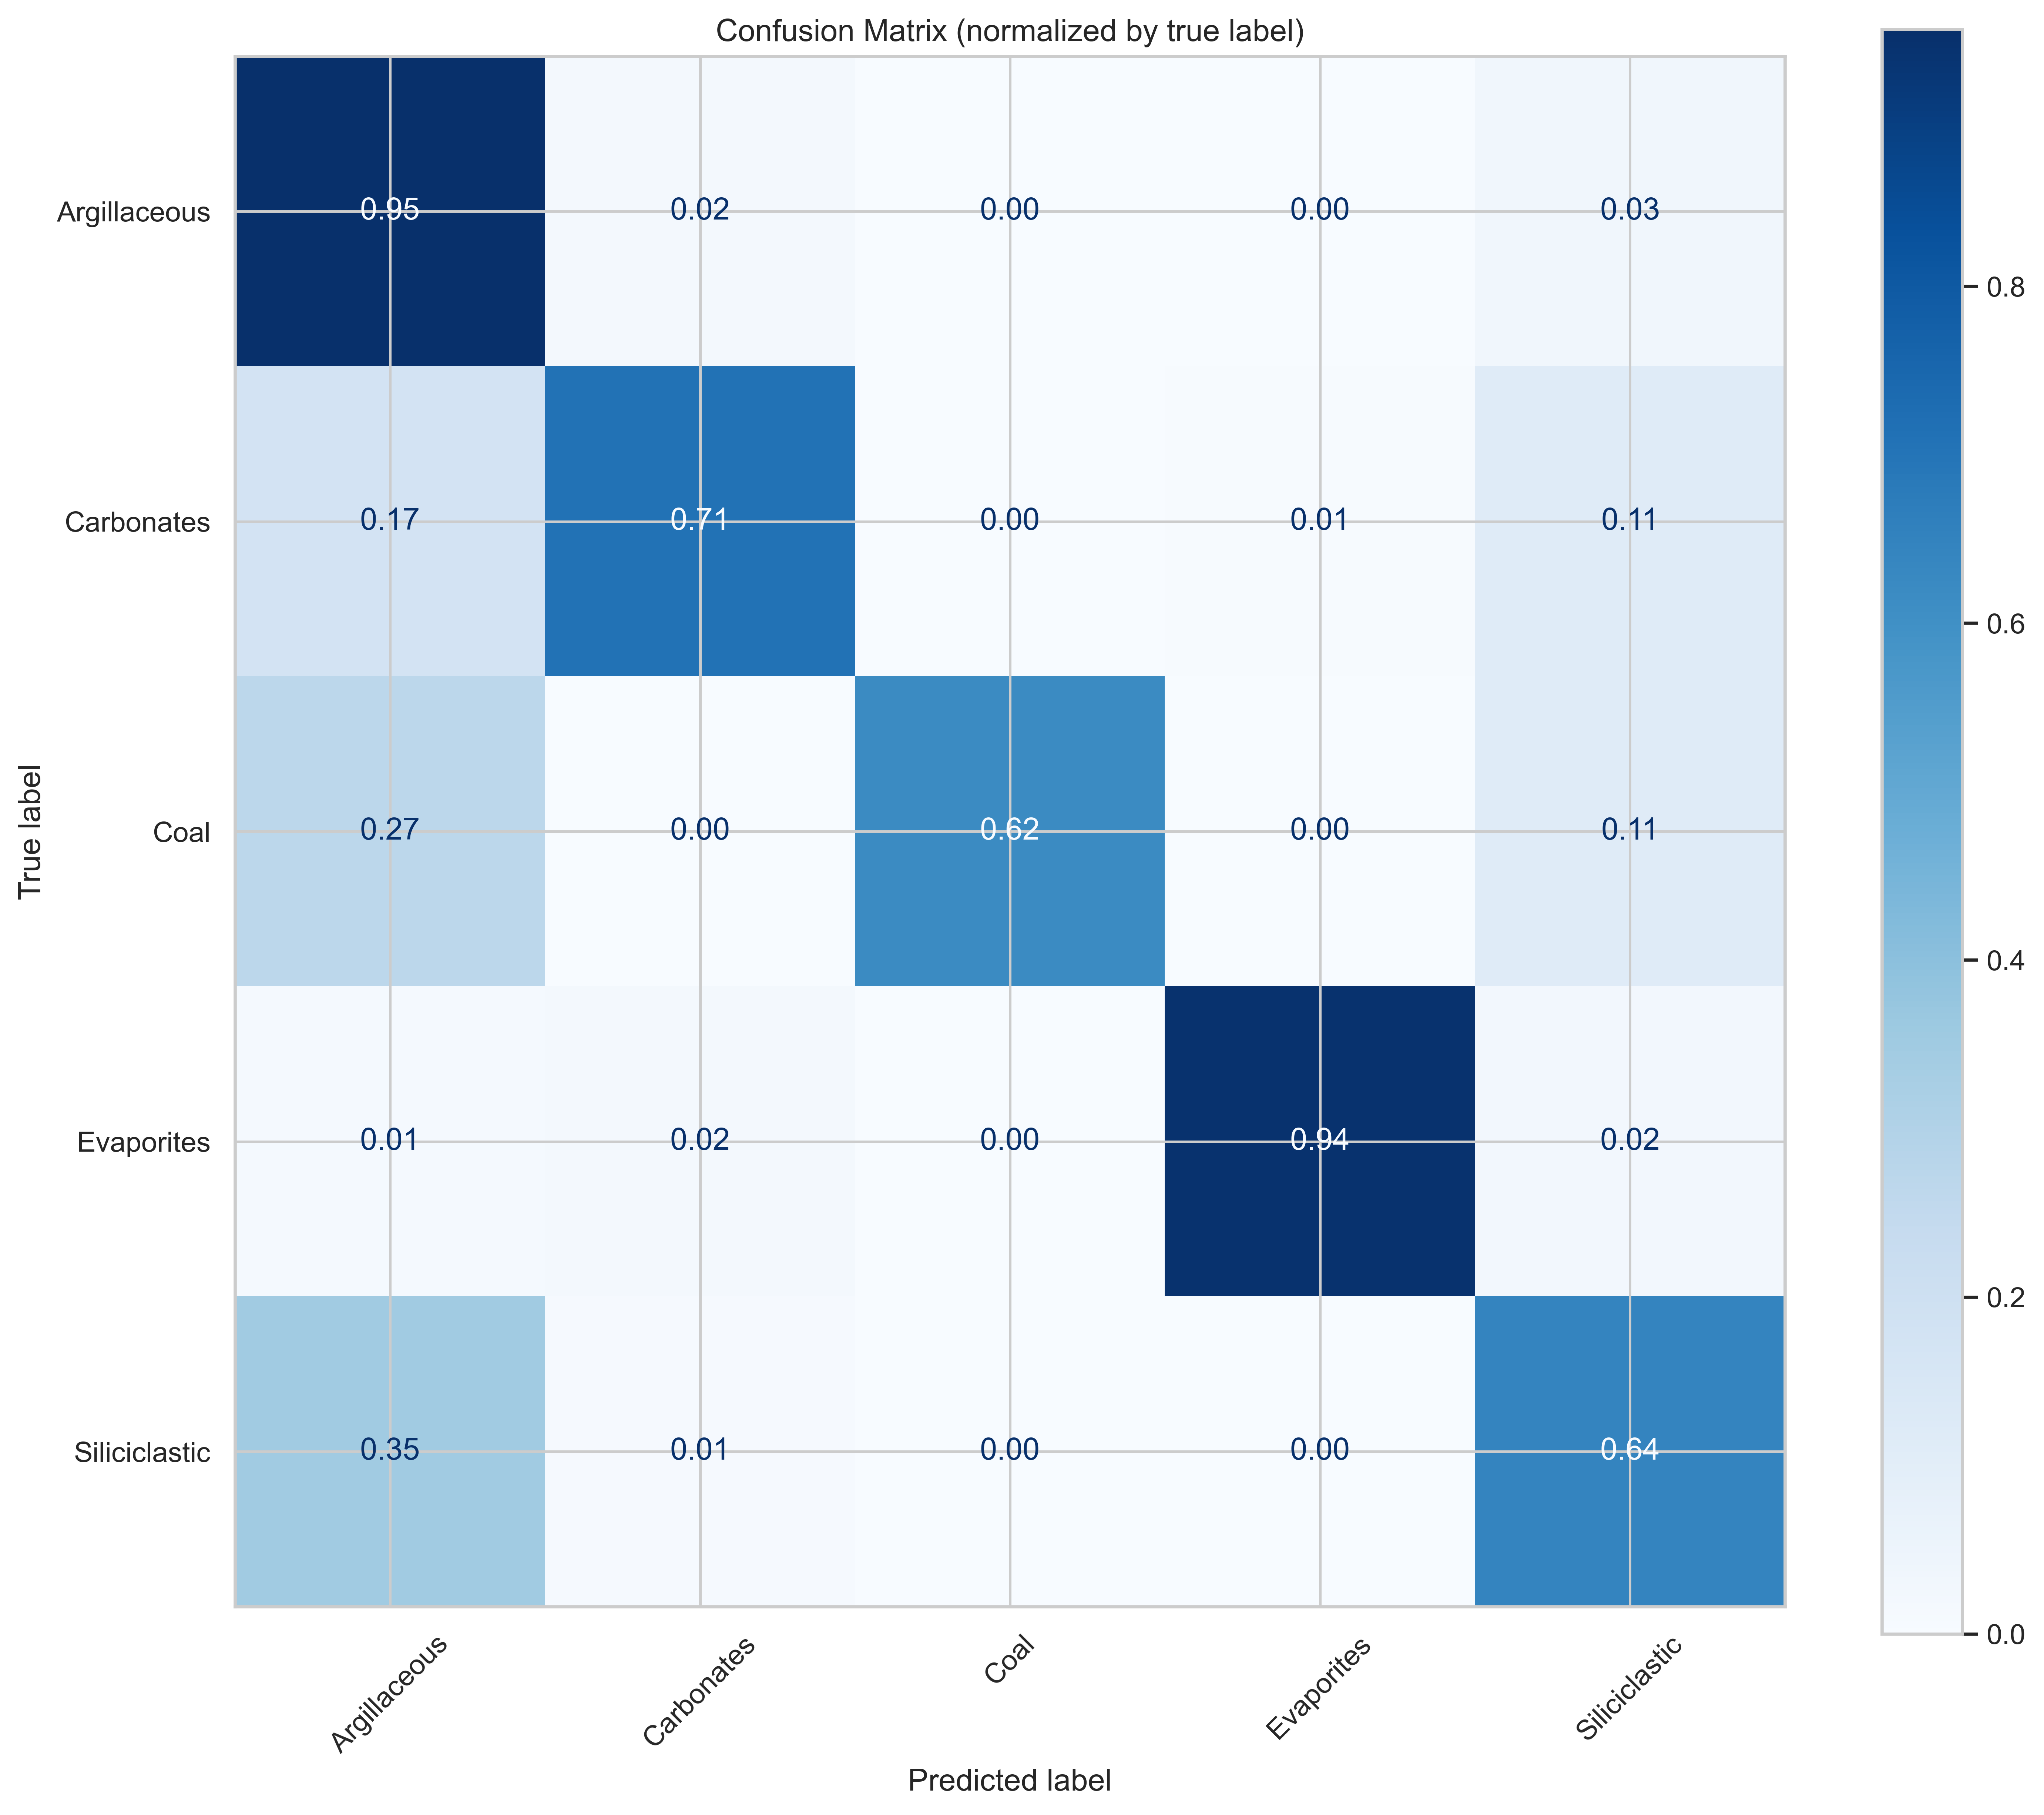

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/hyperimpute_rf_test/roc_auc_curves.png


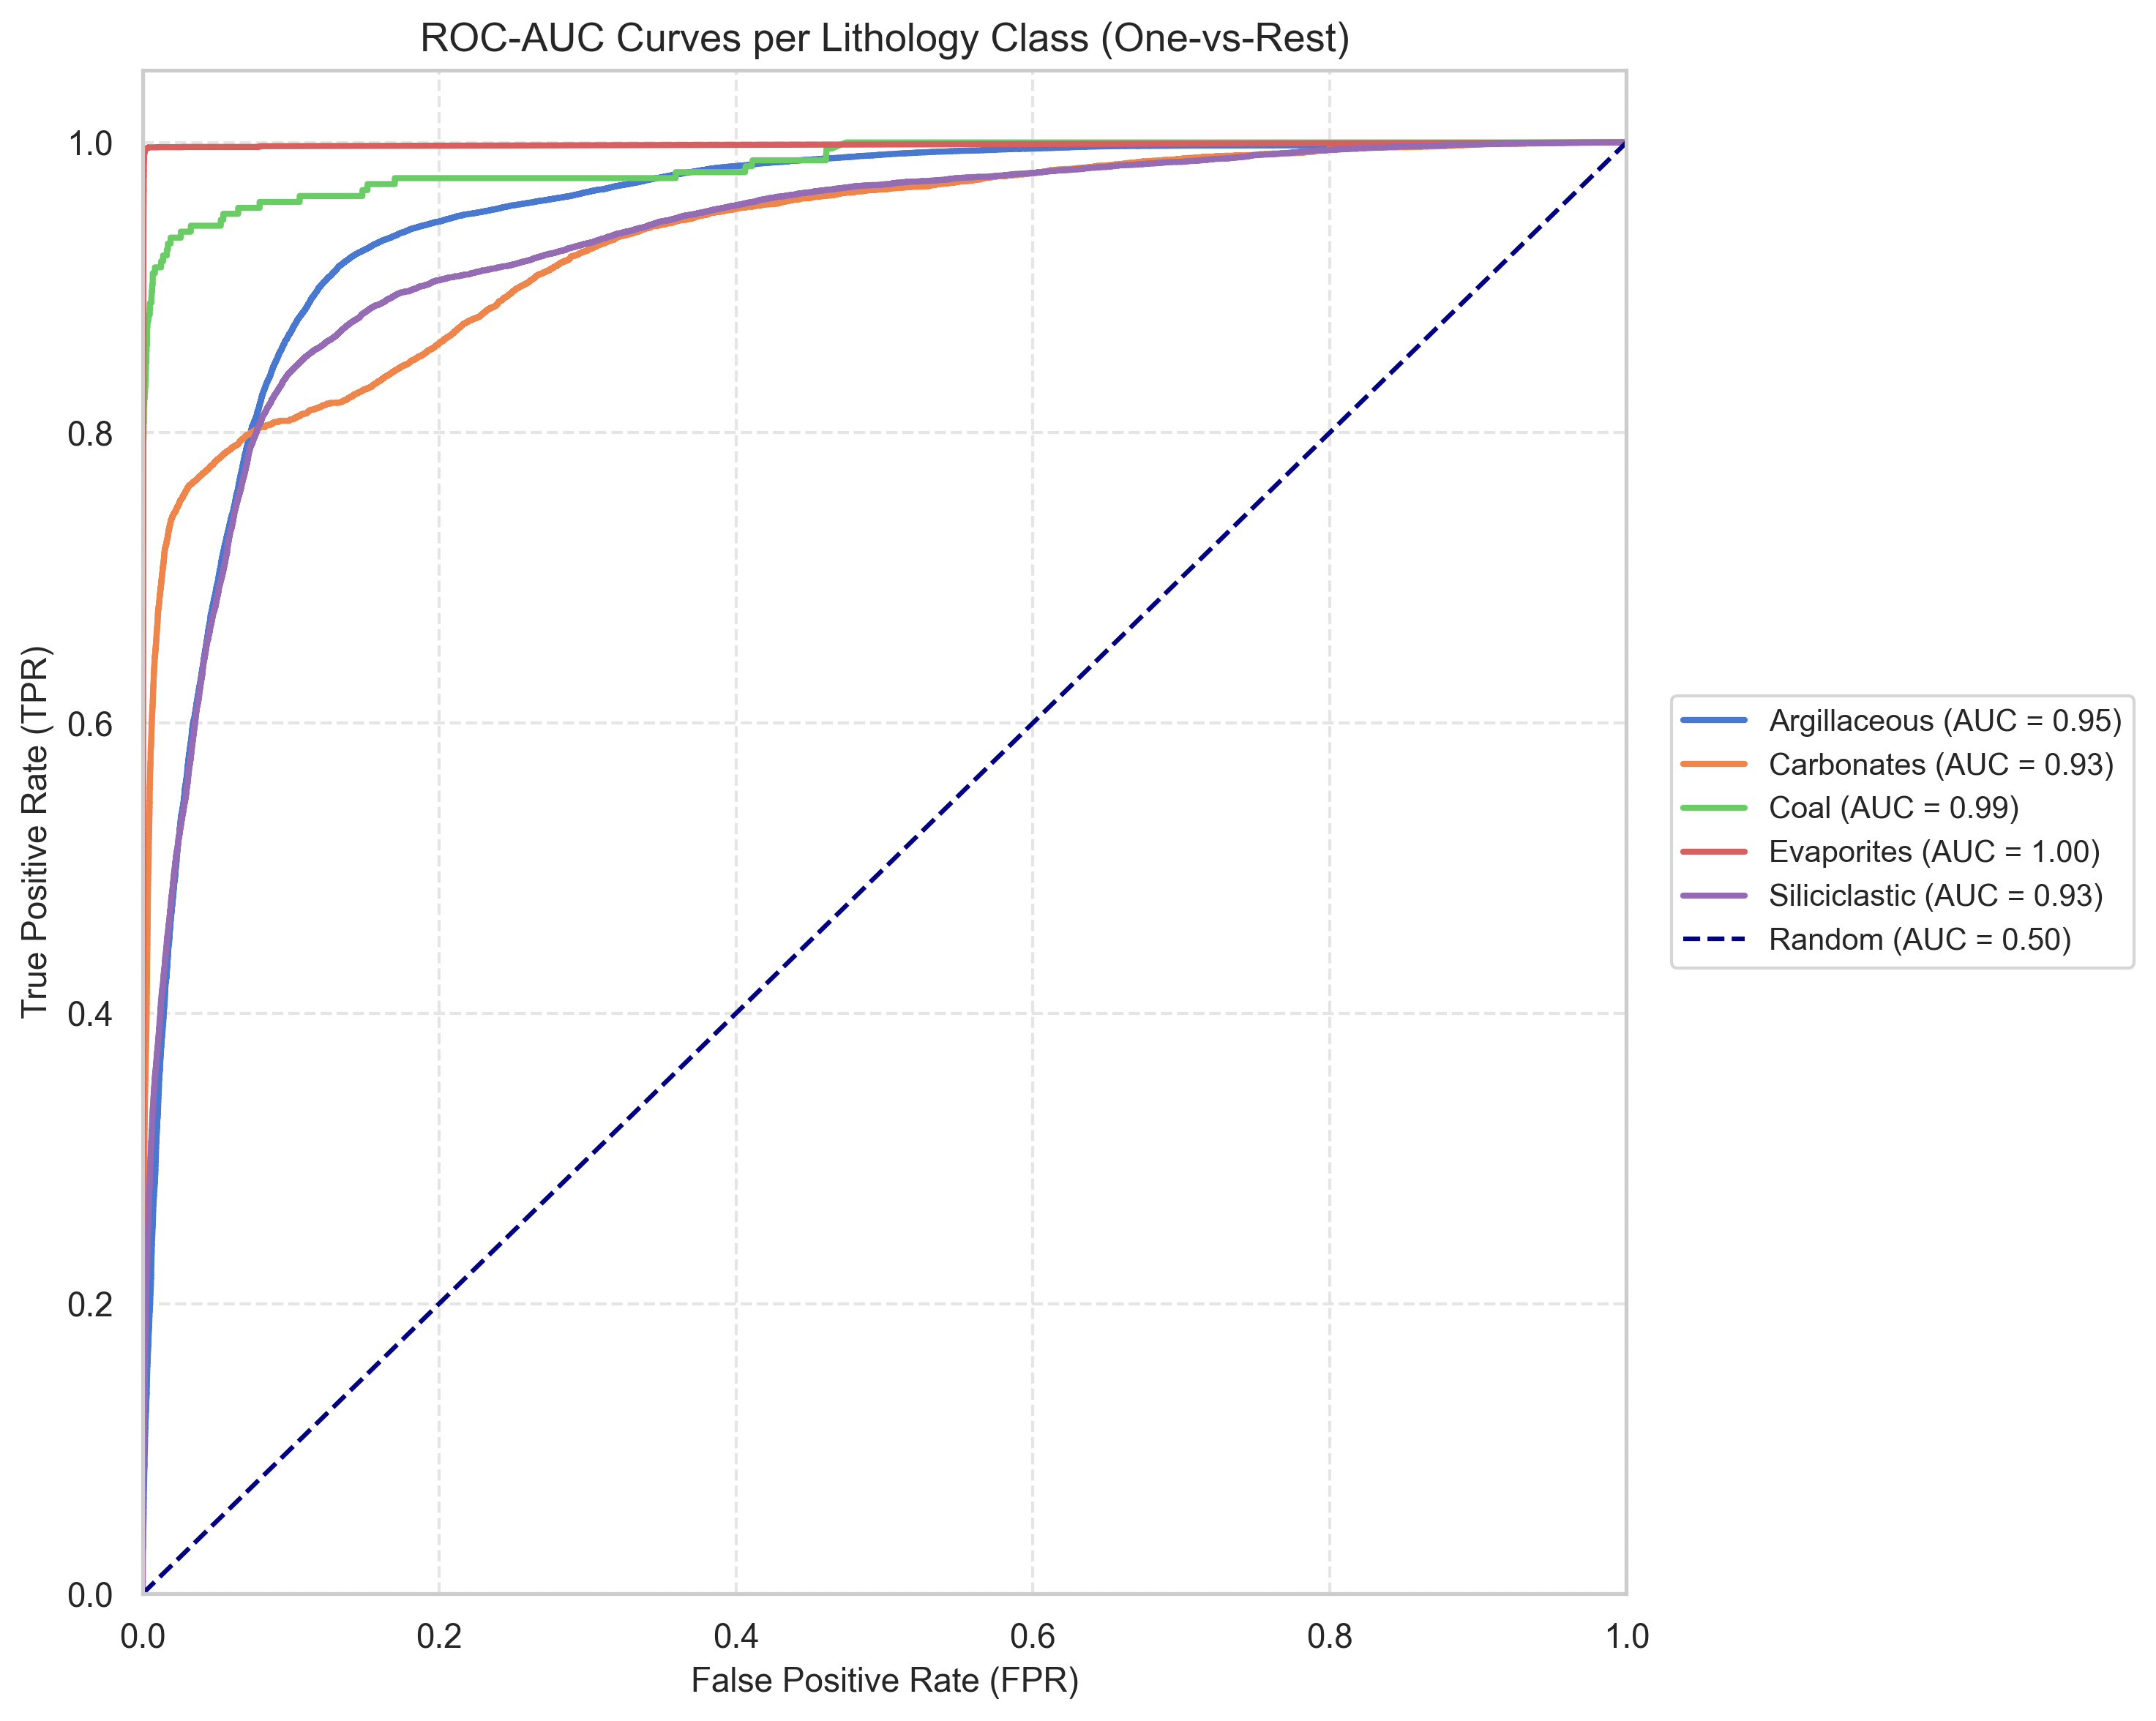

TypeError: '<' not supported between instances of 'float' and 'str'

In [1]:
import sys
import pandas as pd
from pathlib import Path

from sklearn.metrics import classification_report


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
    
from src.models.hyperimpute_wrapper import HyperImputeWrapper
from src import GeophysicalFeatureExtractor, DataCleansing
from src.class_grouper import LithologyClassGrouper
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator

df_train = pd.read_csv(BASE_DIR / "data/raw/train.csv", sep=';')
df_test = pd.read_csv(BASE_DIR / "data/raw/hidden_test.csv", sep=';')
df_test['WELL'] = df_test['WELL'].values
df_train['WELL'] = df_train['WELL'].values
feature_cols = ['RDEP', 'RMED', 'RSHA', 'RHOB', 'GR', 'NPHI', 'DTC']


imputer = HyperImputeWrapper(feature_cols=feature_cols, method="missforest")

df_train_imp = imputer.fit_transform(df_train)
df_test_imp = imputer.transform(df_test)

geo_extractor = GeophysicalFeatureExtractor()
df_train_geo = geo_extractor.transform(df_train_imp)
df_test_geo = geo_extractor.transform(df_test_imp)

cleansing = DataCleansing(
    cols_to_drop=[
        "X_LOC", "Y_LOC", "FORMATION", "SGR", "ROP", "PEF", 
        "RXO", "MUDWEIGHT", "DCAL", "RMIC", "ROPA",
        "FORCE_2020_LITHOFACIES_CONFIDENCE", "LITHO_NAME"
    ],
    cols_to_log=['RDEP', 'RMED', 'RSHA']
)
df_train_final = cleansing.transform(df_train_geo)
df_test_final = cleansing.transform(df_test_geo)


united_classes = {
    'Argillaceous': [65000, 80000, 99000],
    'Siliciclastic': [30000, 65030],
    'Carbonates': [70000, 70032, 74000],
    'Evaporites': [86000, 88000],
    'Coal': 90000,
    'Basement': 93000
}
grouper = LithologyClassGrouper(united_classes)

df_train_grouped = grouper.transform(df_train_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
df_test_grouped = grouper.transform(df_test_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')

trainer = RandomForest(test_size=0.2, random_state=42)
trainer.tune_optuna(df_train_grouped, n_trials=5)

test_preds = trainer.predict(df_test_grouped)
test_probs = trainer.predict_proba(df_test_grouped)

from sklearn.metrics import classification_report

print("Отчет по классификации (Test):")
print(classification_report(df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'], test_preds))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'],
    y_pred=test_preds,
    val_probs=test_probs,
    classes=trainer.pipeline.classes_,
    output_dir=str(BASE_DIR / "reports/figures/hyperimpute_rf_test"),
)

print("HyperImpute завершен!")

In [5]:
from sklearn.metrics import classification_report

print("Отчет по классификации (Test):")
print(classification_report(df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'], test_preds))

Отчет по классификации (Test):
               precision    recall  f1-score   support

 Argillaceous       0.87      0.95      0.91     77164
   Carbonates       0.84      0.71      0.77     11566
         Coal       0.89      0.62      0.73       244
   Evaporites       0.99      0.94      0.97      7095
Siliciclastic       0.81      0.64      0.72     26328

     accuracy                           0.86    122397
    macro avg       0.88      0.77      0.82    122397
 weighted avg       0.86      0.86      0.86    122397



Обучение HyperImpute (missforest) на 8 признаках >>> 
Запуск Optuna (5 итераций) >>>

[Optuna] Лучшие найденные параметры:
  n_estimators: 200
  max_depth: 19
  min_samples_split: 11
  min_samples_leaf: 4
  max_features: log2
  class_weight: None
[Optuna] Лучший Validation F1 Weighted: 0.8540

Обучение финальной модели RandomForest >>>

Отчет по классификации (Validation):
               precision    recall  f1-score   support

 Argillaceous       0.87      0.95      0.91    188834
   Carbonates       0.85      0.60      0.71     15501
         Coal       0.81      0.48      0.61       514
   Evaporites       0.99      0.93      0.96      4139
Siliciclastic       0.82      0.67      0.73     67254

     accuracy                           0.86    276242
    macro avg       0.87      0.73      0.78    276242
 weighted avg       0.86      0.86      0.85    276242

Отчет по классификации (Test):
               precision    recall  f1-score   support

 Argillaceous       0.86      0.95     

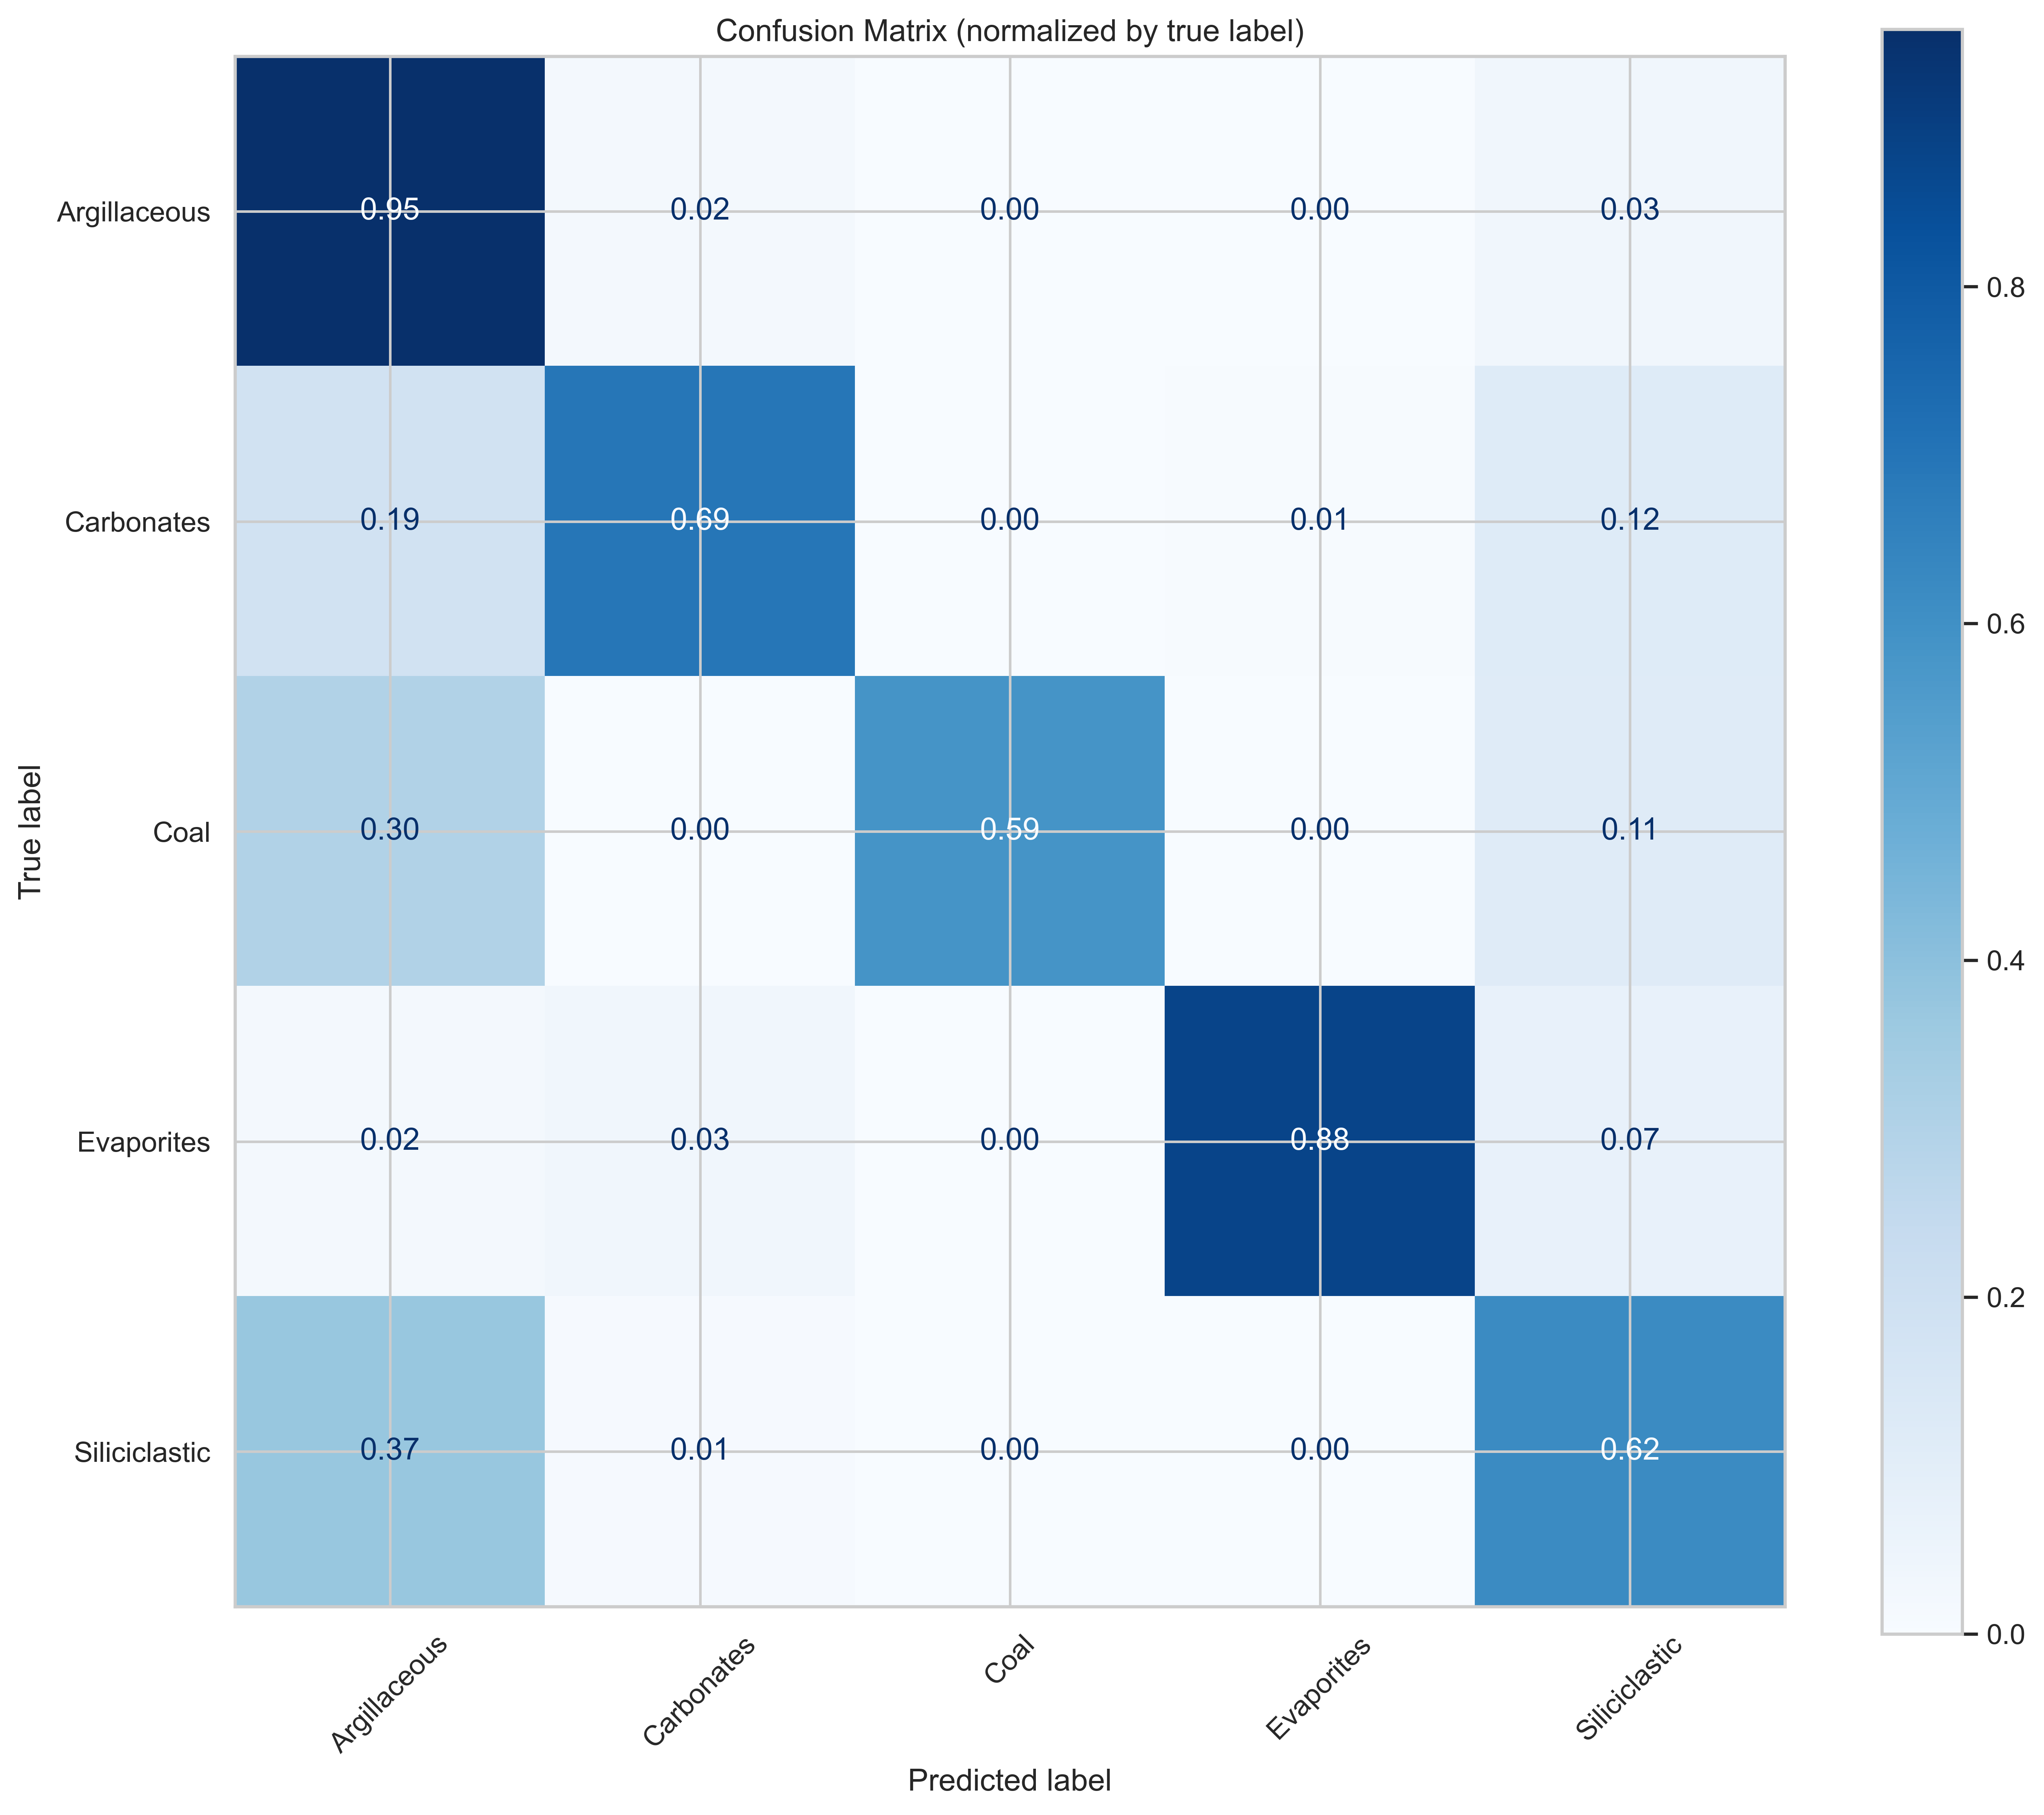

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/hyperimpute_rf_test/roc_auc_curves.png


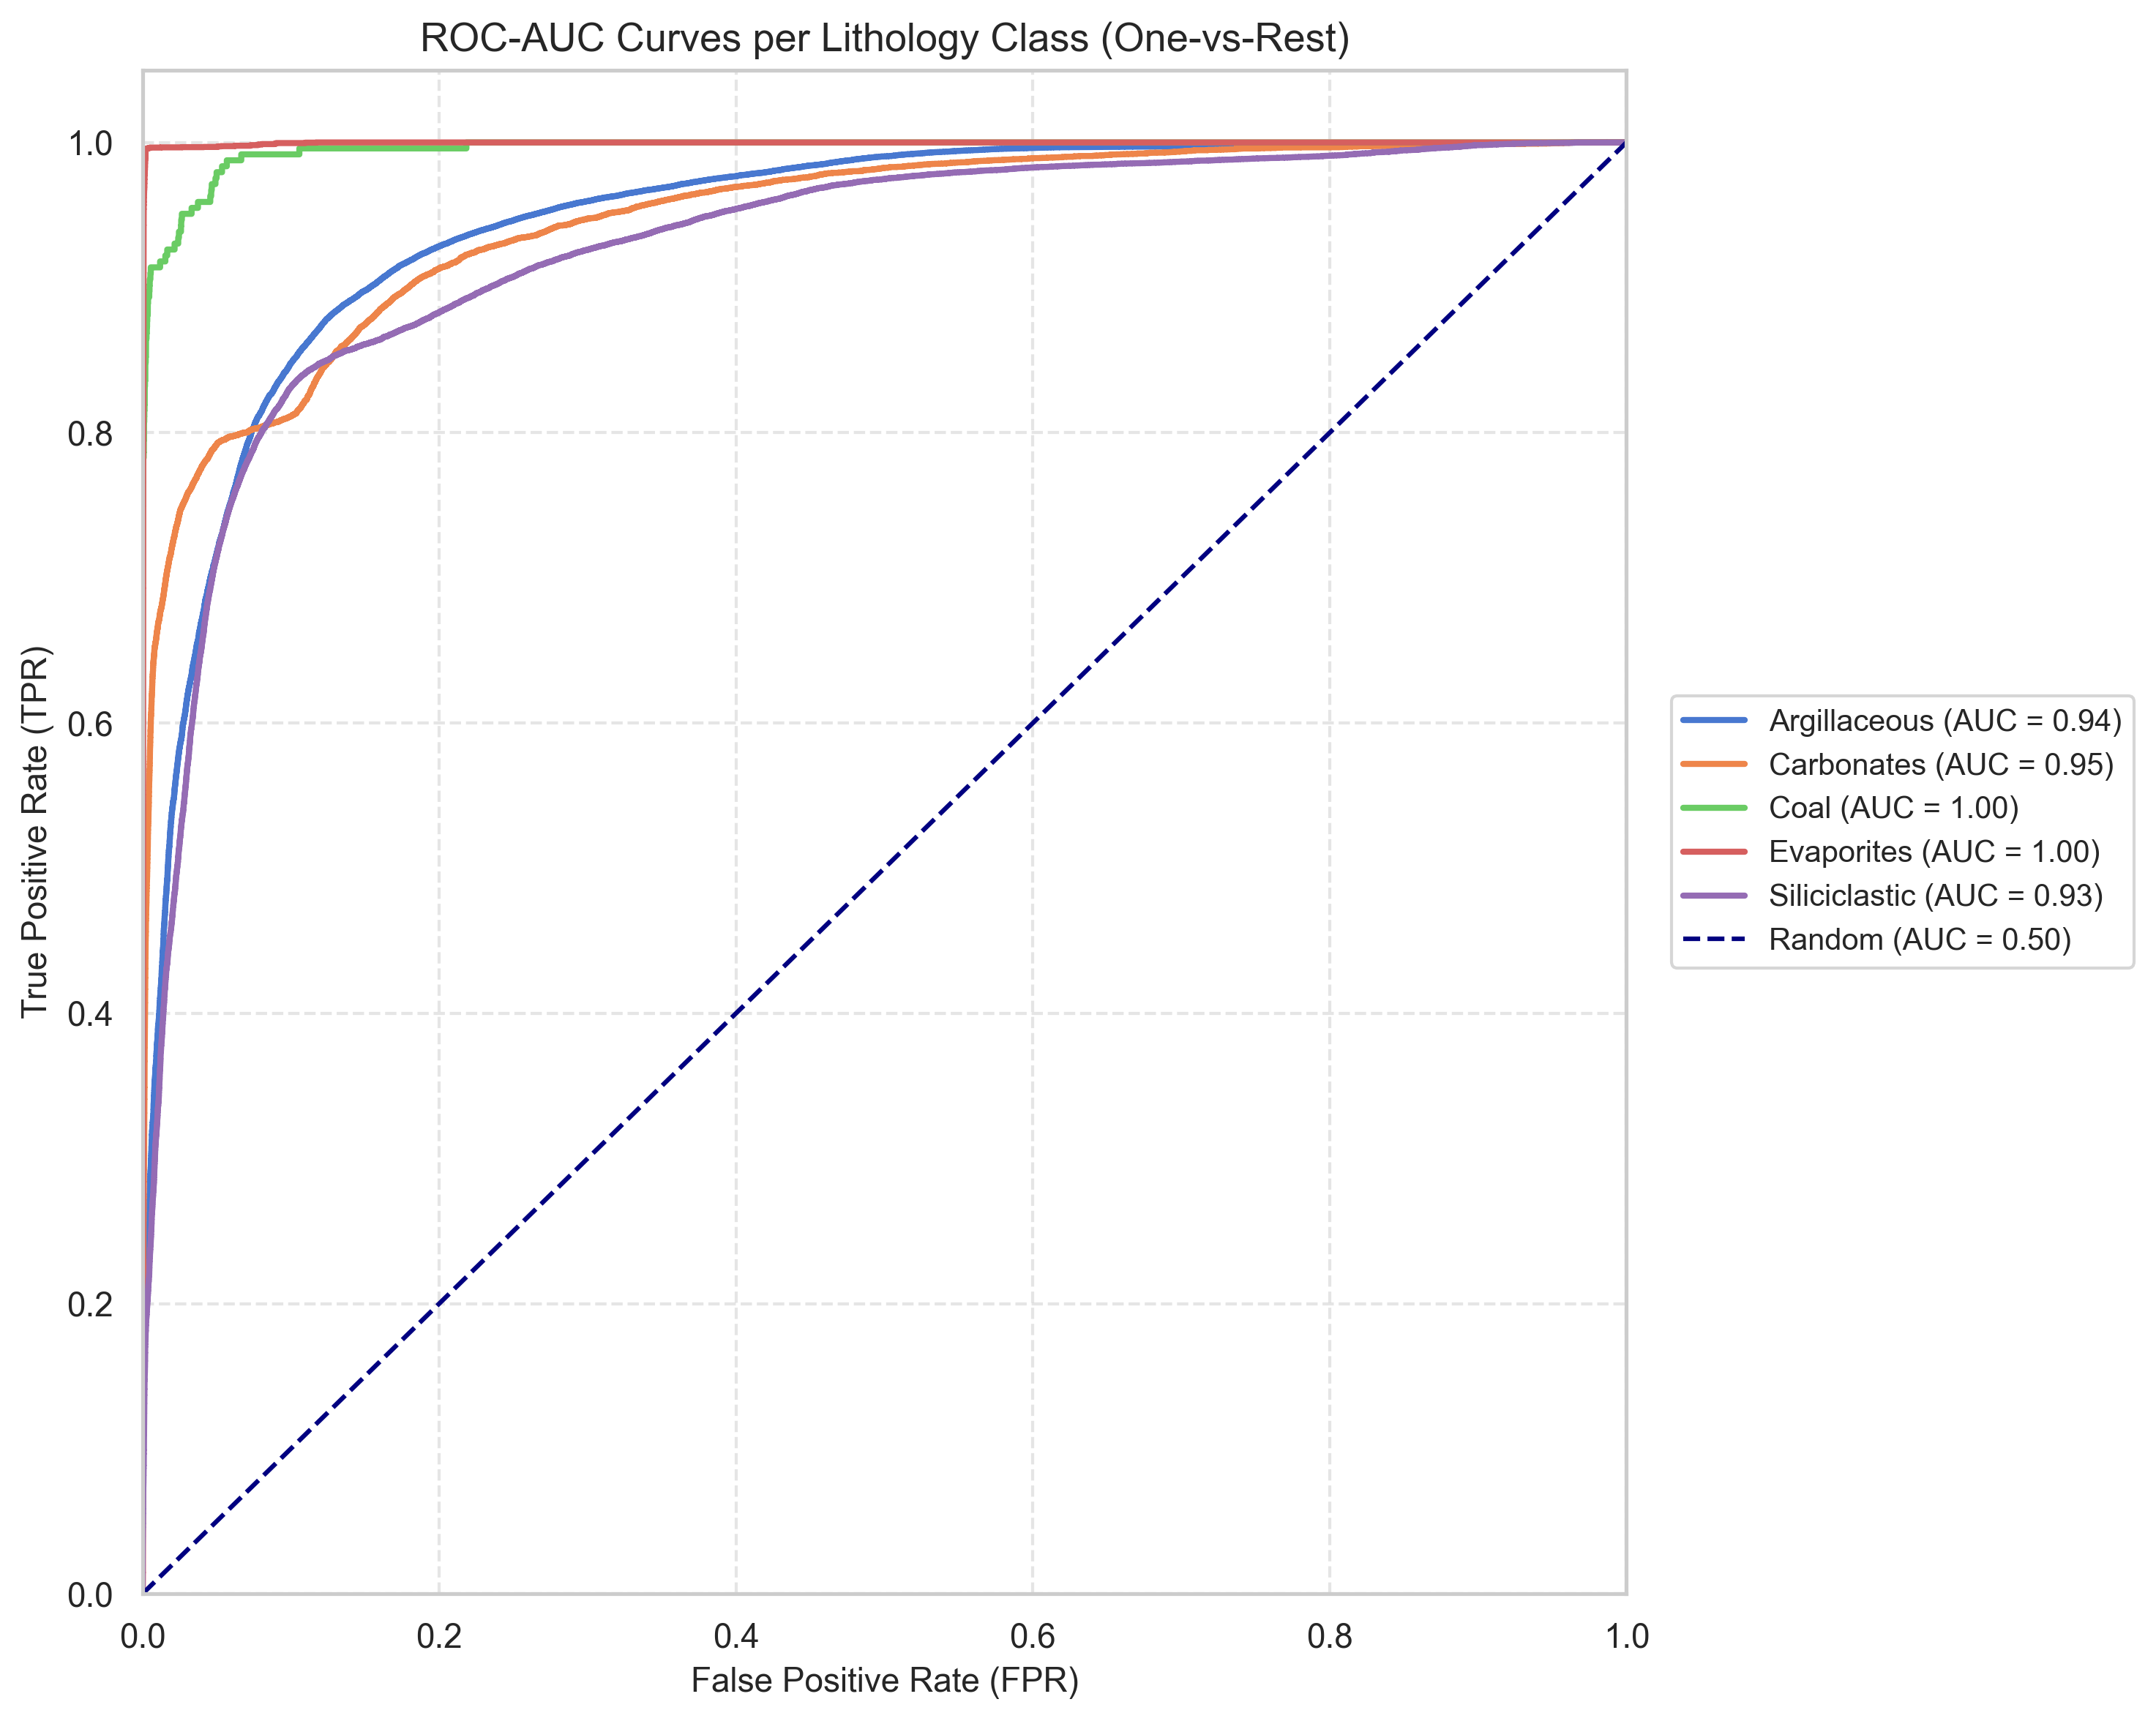

HyperImpute завершен!


In [6]:
import sys
import pandas as pd
from pathlib import Path

from sklearn.metrics import classification_report


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
    
from src.models.hyperimpute_wrapper import HyperImputeWrapper
from src import GeophysicalFeatureExtractor, DataCleansing
from src.class_grouper import LithologyClassGrouper
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator

df_train = pd.read_csv(BASE_DIR / "data/raw/train.csv", sep=';')
df_test = pd.read_csv(BASE_DIR / "data/raw/hidden_test.csv", sep=';')
df_test['WELL'] = df_test['WELL'].values
df_train['WELL'] = df_train['WELL'].values
feature_cols = ['RHOB', 'GR', 'NPHI', 'DTC', 'Z_LOC', 'DTS', 'BS', 'CALI']


imputer = HyperImputeWrapper(feature_cols=feature_cols, method="missforest")

df_train_imp = imputer.fit_transform(df_train)
df_test_imp = imputer.transform(df_test)

geo_extractor = GeophysicalFeatureExtractor()
df_train_geo = geo_extractor.transform(df_train_imp)
df_test_geo = geo_extractor.transform(df_test_imp)

cleansing = DataCleansing(
    cols_to_drop=[
        "X_LOC", "Y_LOC", "FORMATION", "SGR", "ROP", "PEF", 
        "RXO", "MUDWEIGHT", "DCAL", "RMIC", "ROPA",
        "FORCE_2020_LITHOFACIES_CONFIDENCE", "LITHO_NAME"
    ],
    cols_to_log=['RDEP', 'RMED', 'RSHA']
)
df_train_final = cleansing.transform(df_train_geo)
df_test_final = cleansing.transform(df_test_geo)


united_classes = {
    'Argillaceous': [65000, 80000, 99000],
    'Siliciclastic': [30000, 65030],
    'Carbonates': [70000, 70032, 74000],
    'Evaporites': [86000, 88000],
    'Coal': 90000,
    'Basement': 93000
}
grouper = LithologyClassGrouper(united_classes)

df_train_grouped = grouper.transform(df_train_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
df_test_grouped = grouper.transform(df_test_final, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')

trainer = RandomForest(test_size=0.2, random_state=42)
trainer.tune_optuna(df_train_grouped, n_trials=5)

test_preds = trainer.predict(df_test_grouped)
test_probs = trainer.predict_proba(df_test_grouped)

from sklearn.metrics import classification_report

print("Отчет по классификации (Test):")
print(classification_report(df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'], test_preds))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY'],
    y_pred=test_preds,
    val_probs=test_probs,
    classes=trainer.pipeline.classes_,
    output_dir=str(BASE_DIR / "reports/figures/hyperimpute_rf_test"),
)

print("HyperImpute завершен!")